In [1]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


✅ Models 1–4 already trained — loading saved results.
   Skipping re-training to save time.

Downloading: "https://download.pytorch.org/models/convnext_small-0c510722.pth" to /root/.cache/torch/hub/checkpoints/convnext_small-0c510722.pth


100%|██████████| 192M/192M [00:01<00:00, 197MB/s]  



🚀 Training: 5. EmoNeXt (ConvNeXt)
Epoch 1/30 | Loss: 1519.06 | Val Acc: 20.87% | LR: 0.000293 | Patience: 0/7
  ✅ New best saved: 20.87%
Epoch 2/30 | Loss: 1349.09 | Val Acc: 48.96% | LR: 0.000271 | Patience: 0/7
  ✅ New best saved: 48.96%
Epoch 3/30 | Loss: 1295.71 | Val Acc: 37.38% | LR: 0.000238 | Patience: 0/7
Epoch 4/30 | Loss: 1258.23 | Val Acc: 54.31% | LR: 0.000196 | Patience: 1/7
  ✅ New best saved: 54.31%
Epoch 5/30 | Loss: 1231.26 | Val Acc: 46.00% | LR: 0.000150 | Patience: 0/7
Epoch 6/30 | Loss: 1202.81 | Val Acc: 49.97% | LR: 0.000104 | Patience: 1/7
Epoch 7/30 | Loss: 1193.08 | Val Acc: 57.01% | LR: 0.000062 | Patience: 2/7
  ✅ New best saved: 57.01%
Epoch 8/30 | Loss: 1154.67 | Val Acc: 58.89% | LR: 0.000029 | Patience: 0/7
  ✅ New best saved: 58.89%
Epoch 9/30 | Loss: 1134.89 | Val Acc: 61.94% | LR: 0.000007 | Patience: 0/7
  ✅ New best saved: 61.94%
Epoch 10/30 | Loss: 1120.79 | Val Acc: 61.23% | LR: 0.000000 | Patience: 0/7
Epoch 11/30 | Loss: 1115.86 | Val Acc: 61.

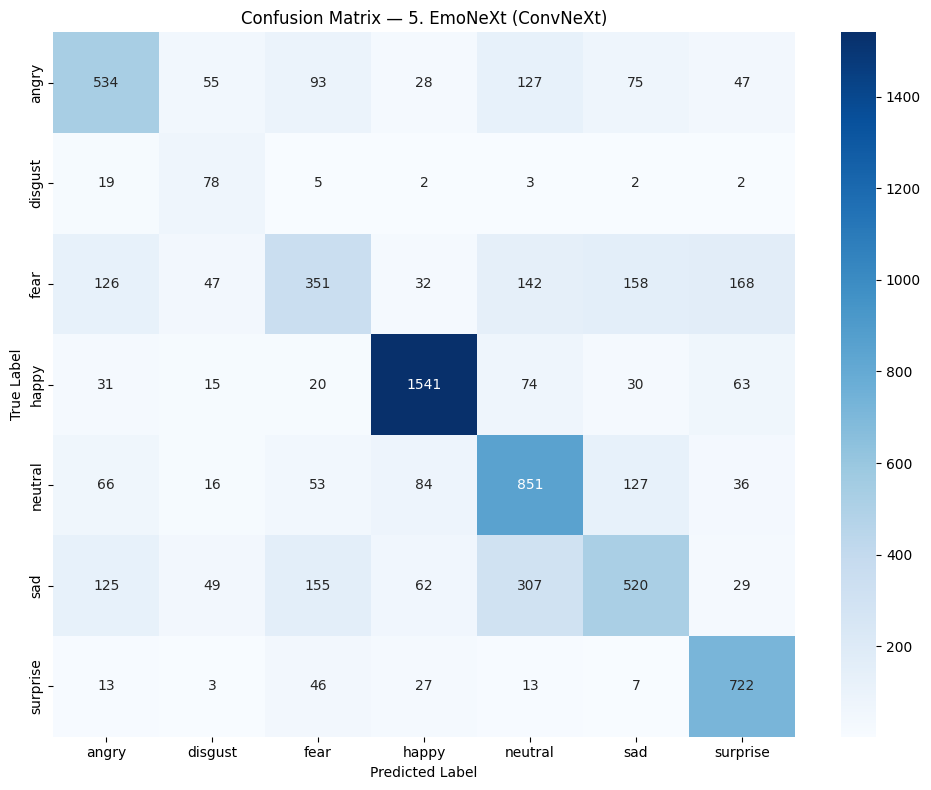


              📊 FINAL MODEL COMPARISON
Model                            Accuracy  F1 Weighted   F1 Macro
-----------------------------------------------------------------
1. Baseline ResNet50               63.83%       63.74%      59.63%
2. Label Smoothing                 65.29%       65.25%      60.77%
3. ResNet50 + CBAM                 65.93%       65.88%      60.63%
4. ResNet50 + STN + CBAM           66.11%       66.33%      61.80%
5. EmoNeXt (ConvNeXt)              64.03%       63.22%      58.82%

🏆 Best Model: 4. ResNet50 + STN + CBAM → 66.11%


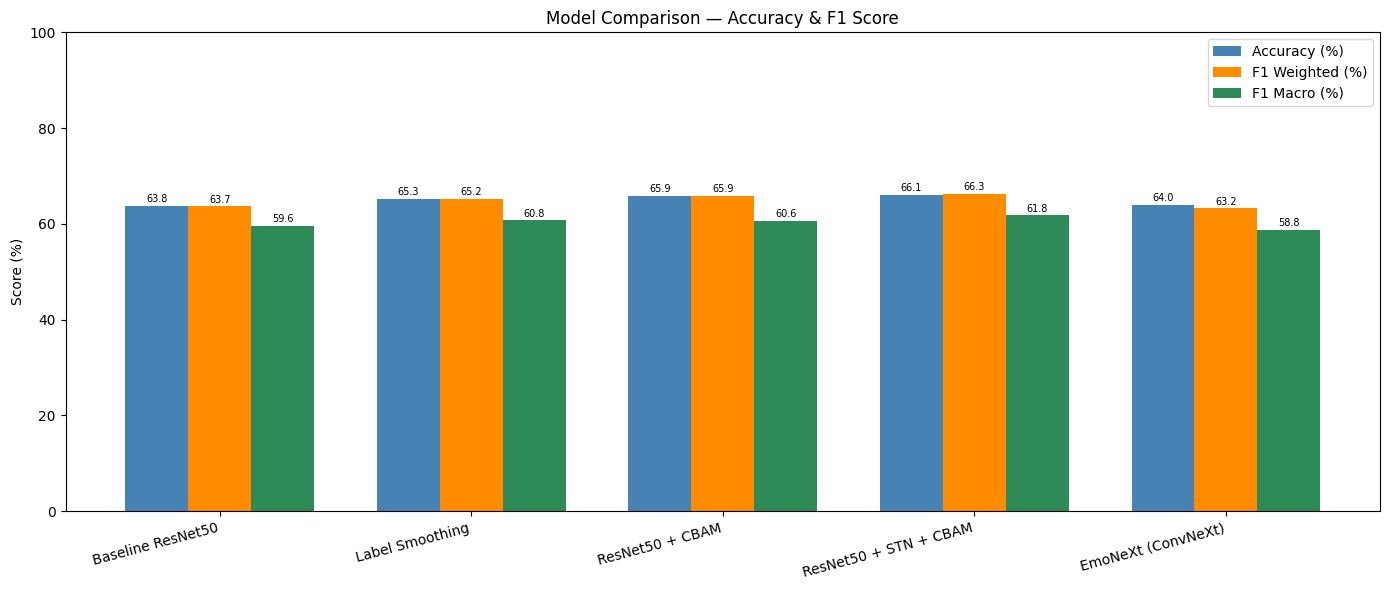

In [2]:
# ── Imports ────────────────────────────────────────────────────────────────
import os
import numpy as np
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torchvision.models import ResNet50_Weights, ConvNeXt_Small_Weights
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

# ── Config ─────────────────────────────────────────────────────────────────
BATCH_SIZE = 32
NUM_EPOCHS = 30
LR         = 0.0005

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR = "/kaggle/working/"
os.makedirs(SAVE_DIR, exist_ok=True)

TRAIN_DIR = "/kaggle/input/datasets/ahmedbasio/emotion-dataset/archive (1) - Copy/train"
TEST_DIR  = "/kaggle/input/datasets/ahmedbasio/emotion-dataset/archive (1) - Copy/test"

# ── Dataset ────────────────────────────────────────────────────────────────
class EmotionDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.images      = []
        self.labels      = []
        self.transform   = transform
        self.class_names = sorted(os.listdir(root_dir))

        for label, cls in enumerate(self.class_names):
            folder = os.path.join(root_dir, cls)
            if not os.path.isdir(folder):
                continue
            for img in os.listdir(folder):
                self.images.append(os.path.join(folder, img))
                self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.images[idx]).convert("RGB")
        except:
            return self.__getitem__((idx + 1) % len(self.images))
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# ── Transforms ─────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.ColorJitter(0.3, 0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ── Load Data ──────────────────────────────────────────────────────────────
full_train = EmotionDataset(TRAIN_DIR, train_transform)

val_size   = int(0.2 * len(full_train))
train_size = len(full_train) - val_size

train_dataset, val_dataset = random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
test_dataset = EmotionDataset(TEST_DIR, test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

num_classes = len(full_train.class_names)
class_names = full_train.class_names

# ── Class Weights ──────────────────────────────────────────────────────────
counts  = Counter(full_train.labels)
total   = sum(counts.values())
weights = [total / counts[i] for i in range(num_classes)]
weights = torch.tensor(weights).float().to(DEVICE)

# ── MixUp ──────────────────────────────────────────────────────────────────
def mixup(x, y, alpha=0.2):
    lam   = np.random.beta(alpha, alpha)
    idx   = torch.randperm(x.size(0)).to(DEVICE)
    mixed = lam * x + (1 - lam) * x[idx]
    return mixed, y, y[idx], lam

# ══════════════════════════════════════════════════════════════════════════
# CBAM
# ══════════════════════════════════════════════════════════════════════════
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg  = self.fc(self.avg_pool(x).squeeze(-1).squeeze(-1))
        max_ = self.fc(self.max_pool(x).squeeze(-1).squeeze(-1))
        return x * self.sigmoid(avg + max_).unsqueeze(-1).unsqueeze(-1)


class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size=7, padding=3)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg     = torch.mean(x, dim=1, keepdim=True)
        max_, _ = torch.max(x, dim=1, keepdim=True)
        return x * self.sigmoid(self.conv(torch.cat([avg, max_], dim=1)))


class CBAM(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.channel = ChannelAttention(in_channels)
        self.spatial = SpatialAttention()

    def forward(self, x):
        return self.spatial(self.channel(x))


# ══════════════════════════════════════════════════════════════════════════
# STN
# ══════════════════════════════════════════════════════════════════════════
class STN(nn.Module):
    def __init__(self):
        super().__init__()
        self.localization = nn.Sequential(
            nn.Conv2d(3, 8,  kernel_size=7), nn.MaxPool2d(2, stride=2), nn.ReLU(True),
            nn.Conv2d(8, 10, kernel_size=5), nn.MaxPool2d(2, stride=2), nn.ReLU(True),
        )
        self.fc_loc = None  # built dynamically

    def forward(self, x):
        xs = self.localization(x).view(x.size(0), -1)
        if self.fc_loc is None:
            self.fc_loc = nn.Sequential(
                nn.Linear(xs.shape[1], 256), nn.ReLU(True),
                nn.Linear(256, 6)
            ).to(x.device)
            self.fc_loc[2].weight.data.zero_()
            self.fc_loc[2].bias.data.copy_(
                torch.tensor([1, 0, 0, 0, 1, 0], dtype=torch.float)
            )
        theta = self.fc_loc(xs).view(-1, 2, 3)
        grid  = F.affine_grid(theta, x.size(), align_corners=False)
        return F.grid_sample(x, grid, align_corners=False)


# ══════════════════════════════════════════════════════════════════════════
# Model Definitions
# ══════════════════════════════════════════════════════════════════════════
class BaselineResNet50(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base = models.resnet50(weights=ResNet50_Weights.DEFAULT)
        for p in base.parameters():
            p.requires_grad = False
        for p in base.layer4.parameters():
            p.requires_grad = True
        base.fc = nn.Linear(base.fc.in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)


class ResNet50LabelSmoothing(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base = models.resnet50(weights=ResNet50_Weights.DEFAULT)
        for p in base.parameters():
            p.requires_grad = False
        for p in base.layer4.parameters():
            p.requires_grad = True
        base.fc = nn.Linear(base.fc.in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)


class ResNet50WithCBAM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base          = models.resnet50(weights=ResNet50_Weights.DEFAULT)
        self.features = nn.Sequential(*list(base.children())[:-2])
        self.cbam     = CBAM(2048)
        self.pool     = nn.AdaptiveAvgPool2d(1)
        self.fc       = nn.Linear(2048, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        x = self.pool(x)
        return self.fc(x.flatten(1))


class ResNet50WithSTNAndCBAM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.stn      = STN()
        base          = models.resnet50(weights=ResNet50_Weights.DEFAULT)
        self.features = nn.Sequential(*list(base.children())[:-2])
        self.cbam     = CBAM(2048)
        self.pool     = nn.AdaptiveAvgPool2d(1)
        self.fc       = nn.Linear(2048, num_classes)

    def forward(self, x):
        x = self.stn(x)
        x = self.features(x)
        x = self.cbam(x)
        x = self.pool(x)
        return self.fc(x.flatten(1))


class EmoNeXt(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base            = models.convnext_small(weights=ConvNeXt_Small_Weights.DEFAULT)
        self.features   = base.features
        self.avgpool    = base.avgpool
        in_features     = base.classifier[2].in_features
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.LayerNorm(in_features),
            nn.Linear(in_features, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        return self.classifier(x)


# ══════════════════════════════════════════════════════════════════════════
# Train + Evaluate Function
# ══════════════════════════════════════════════════════════════════════════
def train_and_evaluate(model, name, criterion, optimizer, scheduler,
                       epochs=NUM_EPOCHS, patience=7):

    print(f"\n{'='*55}")
    print(f"🚀 Training: {name}")
    print(f"{'='*55}")

    safe_name       = name.replace(' ', '_')
    checkpoint_path = os.path.join(SAVE_DIR, f"{safe_name}_checkpoint.pth")
    best_model_path = os.path.join(SAVE_DIR, f"{safe_name}_best.pth")

    start_epoch = 0
    best_acc    = 0
    counter     = 0

    if os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        start_epoch = ckpt['epoch'] + 1
        best_acc    = ckpt['best_acc']
        counter     = ckpt['counter']
        print(f"🔄 Resuming from epoch {start_epoch} | Best so far: {best_acc:.2f}%")

    for epoch in range(start_epoch, epochs):

        model.train()
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()

            if epoch < 15:
                x, y_a, y_b, lam = mixup(x, y)
                out  = model(x)
                loss = lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)
            else:
                out  = model(x)
                loss = criterion(out, y)

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()

        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y    = x.to(DEVICE), y.to(DEVICE)
                out     = model(x)
                _, pred = torch.max(out, 1)
                total   += y.size(0)
                correct += (pred == y).sum().item()

        val_acc    = 100 * correct / total
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.2f} | "
              f"Val Acc: {val_acc:.2f}% | LR: {current_lr:.6f} | "
              f"Patience: {counter}/{patience}")

        torch.save({
            'epoch':     epoch,
            'model':     model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'best_acc':  best_acc,
            'counter':   counter
        }, checkpoint_path)

        if val_acc > best_acc:
            best_acc = val_acc
            counter  = 0
            torch.save(model.state_dict(), best_model_path)
            print(f"  ✅ New best saved: {best_acc:.2f}%")
        else:
            counter += 1

        if counter >= patience:
            print(f"⛔ Early Stopping at epoch {epoch+1} "
                  f"(no improvement for {patience} epochs)")
            break

    # ── Test ───────────────────────────────────────────────────────────────
    model.load_state_dict(torch.load(best_model_path))
    model.eval()

    preds_list, labels_list = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x    = x.to(DEVICE)
            out  = model(x)
            _, p = torch.max(out, 1)
            preds_list.extend(p.cpu().numpy())
            labels_list.extend(y.numpy())

    acc  = accuracy_score(labels_list, preds_list) * 100
    f1_w = f1_score(labels_list, preds_list, average='weighted')
    f1_m = f1_score(labels_list, preds_list, average='macro')

    print(f"\n🔥 {name} TEST ACCURACY : {acc:.2f}%")
    print(f"   F1 Weighted        : {f1_w:.4f}")
    print(f"   F1 Macro           : {f1_m:.4f}")
    print(f"\n📊 Classification Report — {name}:")
    print(classification_report(labels_list, preds_list, target_names=class_names))

    cm = confusion_matrix(labels_list, preds_list)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"{safe_name}_confusion_matrix.png"), dpi=150)
    plt.show()

    return acc, f1_w, f1_m


# ══════════════════════════════════════════════════════════════════════════
# Results — hardcode already-finished models, only run EmoNeXt
# ══════════════════════════════════════════════════════════════════════════
results = {
    "1. Baseline ResNet50"    : (63.83, 0.6374, 0.5963),
    "2. Label Smoothing"      : (65.29, 0.6525, 0.6077),
    "3. ResNet50 + CBAM"      : (65.93, 0.6588, 0.6063),
    "4. ResNet50 + STN + CBAM": (66.11, 0.6633, 0.6180),
}

print("✅ Models 1–4 already trained — loading saved results.")
print("   Skipping re-training to save time.\n")

# ── Model 5: EmoNeXt (ConvNeXt-Small) ─────────────────────────────────────
m5   = EmoNeXt(num_classes).to(DEVICE)
opt5 = optim.Adam(m5.parameters(), lr=0.0003, weight_decay=1e-4)
sch5 = torch.optim.lr_scheduler.CosineAnnealingLR(opt5, T_max=10)

results["5. EmoNeXt (ConvNeXt)"] = train_and_evaluate(
    m5, "5. EmoNeXt (ConvNeXt)",
    nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1),
    opt5, sch5
)
del m5, opt5, sch5
torch.cuda.empty_cache()

# ══════════════════════════════════════════════════════════════════════════
# Final Comparison Table + Bar Chart
# ══════════════════════════════════════════════════════════════════════════
names = list(results.keys())
accs  = [results[n][0]       for n in names]
f1_ws = [results[n][1] * 100 for n in names]
f1_ms = [results[n][2] * 100 for n in names]

print("\n" + "="*65)
print("              📊 FINAL MODEL COMPARISON")
print("="*65)
print(f"{'Model':<30} {'Accuracy':>10} {'F1 Weighted':>12} {'F1 Macro':>10}")
print("-"*65)
for n, a, fw, fm in zip(names, accs, f1_ws, f1_ms):
    print(f"{n:<30} {a:>9.2f}%  {fw:>10.2f}%  {fm:>9.2f}%")
print("="*65)
best = max(results, key=lambda n: results[n][0])
print(f"\n🏆 Best Model: {best} → {results[best][0]:.2f}%")

# ── Bar Chart ──────────────────────────────────────────────────────────────
x     = np.arange(len(names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - width, accs,  width, label='Accuracy (%)',    color='steelblue')
b2 = ax.bar(x,         f1_ws, width, label='F1 Weighted (%)', color='darkorange')
b3 = ax.bar(x + width, f1_ms, width, label='F1 Macro (%)',    color='seagreen')

for bar in list(b1) + list(b2) + list(b3):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}',
            ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([n.split('. ', 1)[1] for n in names], rotation=15, ha='right')
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison — Accuracy & F1 Score')
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "comparison_chart.png"), dpi=150)
plt.show()